This notebook is an aggregation of everyone's ML models. It's meant to be run in Google Colab, assuming the user has access to our shared drive `171Project`

# Alex (Multiclass XGBoost)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression


In [3]:
training_set = pd.read_csv('/content/drive/Shareddrives/171Project/dataset/features_train.csv')
validation_set = pd.read_csv('/content/drive/Shareddrives/171Project/dataset/features_val.csv')
test_set = pd.read_csv('/content/drive/Shareddrives/171Project/dataset/features_test.csv')

In [4]:
train_xgb = training_set[training_set['status'] != 'normal'].copy()
train_xgb = train_xgb.drop(columns=['tfidf_vec', 'count_vec', 'bert features'], errors='ignore')

In [5]:
val_xgb = validation_set[validation_set['status'] != 'normal'].copy()
val_xgb = val_xgb.drop(columns=['tfidf_vec', 'count_vec', 'bert features'], errors='ignore')

In [6]:
test_xgb = test_set[test_set['status'] != 'normal'].copy()
test_xgb = test_xgb.drop(columns=['tfidf_vec', 'count_vec', 'bert features'], errors='ignore')

In [7]:
le = LabelEncoder()
y_train = le.fit_transform(train_xgb['status'])
y_val = le.transform(val_xgb['status'])
y_test = le.transform(test_xgb['status'])

In [46]:
import joblib
joblib.dump(le, "label_encoder_xgboost.joblib")


['label_encoder_xgboost.joblib']

In [8]:
num_features = train_xgb.select_dtypes(include=[np.number]).columns.tolist()
num_features

features = num_features + ['statement']

In [9]:
X_train = train_xgb[features]
X_val = val_xgb[features]
X_test = test_xgb[features]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=5, max_df = 0.85), 'statement'),
        ('num', 'passthrough', num_features)
    ])

In [11]:
X_train_fit = preprocessor.fit_transform(X_train)
X_val_fit = preprocessor.transform(X_val)
X_test_fit = preprocessor.transform(X_test)

In [12]:
classes = np.unique(y_train)

weights = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Printing out the weights
class_weights_dict = dict(enumerate(weights))

class_names = le.inverse_transform(classes)

print("--- Abnormal Class Weights ---")
for i, name in enumerate(class_names):
    weight = weights[i]
    print(f"Class {classes[i]} ({name}): {weight:.2f}")

--- Abnormal Class Weights ---
Class 0 (anxiety): 0.57
Class 1 (bipolar): 0.57
Class 2 (depression): 2.34
Class 3 (personality disorder): 0.57
Class 4 (stress): 0.57
Class 5 (suicidal): 1.58


In [13]:
custom_weights = {
    'anxiety': 1.5,
    'bipolar': 2.0,
    'depression': 1.0,
    'personality disorder': 3.0,
    'stress': 2.0,
    'suicidal': 1.2
}

sample_weights = train_xgb['status'].map(custom_weights).values

In [14]:
xgb_model_2 = XGBClassifier(
    num_class = len(classes),
    objective = 'multi:softprob',
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 7,
    subsample = 0.8,
    colsample_bytree = 0.6,
    early_stopping_rounds = 20,
    gamma = 0.2,
    min_child_weight = 10,
    reg_lambda = 3,
    n_jobs = -1,
    device='cuda'
)

In [15]:
xgb_model_2.fit(X_train_fit, y_train, sample_weight=sample_weights, eval_set=[(X_train_fit, y_train), (X_val_fit, y_val)])

[0]	validation_0-mlogloss:1.45524	validation_1-mlogloss:1.45803
[1]	validation_0-mlogloss:1.41962	validation_1-mlogloss:1.42467
[2]	validation_0-mlogloss:1.38495	validation_1-mlogloss:1.39278
[3]	validation_0-mlogloss:1.35247	validation_1-mlogloss:1.36278
[4]	validation_0-mlogloss:1.32540	validation_1-mlogloss:1.33761
[5]	validation_0-mlogloss:1.29765	validation_1-mlogloss:1.31274
[6]	validation_0-mlogloss:1.27238	validation_1-mlogloss:1.28987
[7]	validation_0-mlogloss:1.24904	validation_1-mlogloss:1.26841
[8]	validation_0-mlogloss:1.22508	validation_1-mlogloss:1.24590
[9]	validation_0-mlogloss:1.20182	validation_1-mlogloss:1.22445
[10]	validation_0-mlogloss:1.18176	validation_1-mlogloss:1.20603
[11]	validation_0-mlogloss:1.16274	validation_1-mlogloss:1.18881
[12]	validation_0-mlogloss:1.14330	validation_1-mlogloss:1.17079
[13]	validation_0-mlogloss:1.12735	validation_1-mlogloss:1.15662
[14]	validation_0-mlogloss:1.10957	validation_1-mlogloss:1.14023
[15]	validation_0-mlogloss:1.09272	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device='cuda', early_stopping_rounds=20,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_class=6, ...)

In [ ]:
features = ['first_person_ratio',
 'negatives_ratio',
 'suicide_ratio',
 'reps_ratio',
 'character_count',
 'word_count',
 'avg_word_length',
 'avg_sentence_length_in_words',
 'avg_sentence_length_in_characters',
 'sia_sentiment',
 'statement']

In [17]:
y_val_pred_2 = xgb_model_2.predict(X_val_fit)
print(classification_report(y_val, y_val_pred_2, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:11:54] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


                      precision    recall  f1-score   support

             anxiety       0.85      0.83      0.84       576
             bipolar       0.87      0.75      0.81       416
          depression       0.77      0.75      0.76      2311
personality disorder       0.82      0.64      0.72       162
              stress       0.72      0.76      0.74       388
            suicidal       0.69      0.75      0.72      1598

            accuracy                           0.76      5451
           macro avg       0.79      0.75      0.76      5451
        weighted avg       0.76      0.76      0.76      5451



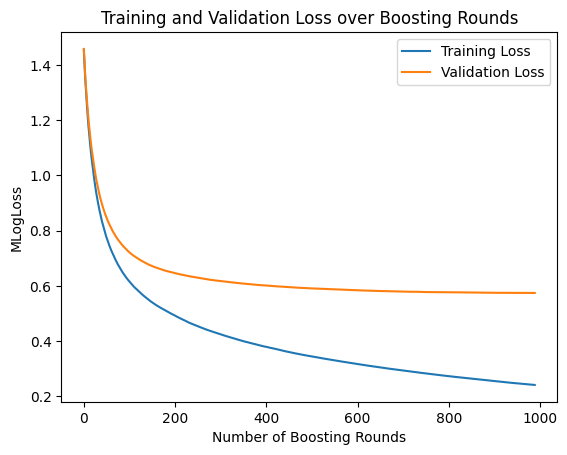

In [18]:
results = xgb_model_2.evals_result()

plt.plot(results['validation_0']['mlogloss'], label='Training Loss')
plt.plot(results['validation_1']['mlogloss'], label='Validation Loss')
plt.title('Training and Validation Loss over Boosting Rounds')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('MLogLoss')
plt.legend()
plt.show()

In [19]:
y_test_pred_2 = xgb_model_2.predict(X_test_fit)
print(classification_report(y_test, y_test_pred_2, target_names=le.classes_))

                      precision    recall  f1-score   support

             anxiety       0.84      0.84      0.84       576
             bipolar       0.88      0.80      0.84       417
          depression       0.78      0.76      0.77      2311
personality disorder       0.82      0.70      0.75       161
              stress       0.78      0.76      0.77       388
            suicidal       0.70      0.77      0.73      1598

            accuracy                           0.77      5451
           macro avg       0.80      0.77      0.79      5451
        weighted avg       0.78      0.77      0.77      5451



In [20]:
accuracy = accuracy_score(y_test, y_test_pred_2)
print("Final Accuracy:", accuracy)

Final Accuracy: 0.7719684461566685


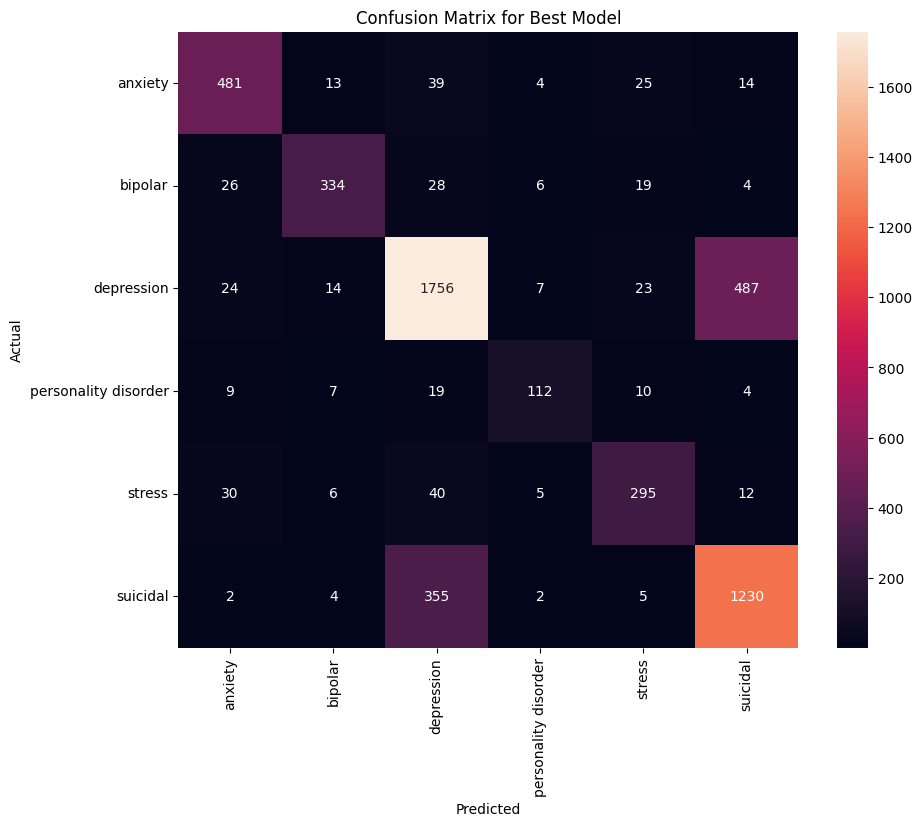

In [21]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred_2)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Exporting for later use

In [ ]:
import joblib
import numpy as np
from nltk.tokenize import sent_tokenize
import make_features_helper as helper
import pandas as pd

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

# Save
joblib.dump((preprocessor, xgb_model_2), "xgb_classifier.joblib")

# Load
loaded_preprocessor, loaded_model = joblib.load("xgb_classifier.joblib")

# Inference
example = X_train.iloc[0]['statement']

# For word ratios
first_person_pronouns = ['i', 'me', 'my', 'mine', 'myself']
negatives = ['no', 'not', 'never', 'nothing', 'wrong', 'nope']
suicide_words = ['die', 'end', 'forever', 'leave', 'gone', 'suicide', 'kill']
ratio_items = {'first_person_ratio' : first_person_pronouns, 'negatives_ratio': negatives, 'suicide_ratio': suicide_words}

# List all functions
feature2function = {
  'word_ratio' : helper.word_ratio,
  'reps_ratio' : helper.reps_ratio,
  'character_count' : helper.character_count,
  'word_count' : helper.word_count,
  'avg_word_length' : helper.avg_word_length,
  'avg_sentence_length_in_words' : helper.avg_sentence_length_in_words,
  'avg_sentence_length_in_characters' : helper.avg_sentence_length_in_characters,
  'sia_sentiment' : helper.sia_sentiment,
}

# Example on how to do inference
vector = []
for column in feature2function.keys():

  function = feature2function[column]

  if column == 'word_ratio':
    for ratio in ratio_items.keys():

      ratio_item = ratio_items[ratio]
      vector.append(function(example, ratio_item))

  elif 'avg_sentence' in column:

    sentences = sent_tokenize(example)
    vector.append(function(sentences))

  else:

    vector.append(function(example))

vector.append(example)
temp = {}
for index, feature in enumerate(features):
  temp[feature] = vector[index]
vector_df = pd.DataFrame([temp])
vector_transformed = loaded_preprocessor.transform(vector_df)
prediction = loaded_model.predict(vector_transformed)

le = joblib.load("label_encoder_xgboost.joblib")
print("Predicted:", le.inverse_transform([prediction])[0])
print("Gronud truth:", le.inverse_transform([y_train[0]])[0])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Predicted: suicidal
Gronud truth: suicidal


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
import sklearn # Sklearn version is important for unpickling the models.
print(sklearn.__version__)

1.6.1


# Laasya (Binary Neural Network)

In [55]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import pandas as pd
from sklearn.utils import class_weight
import numpy as np

train_dataset = "/content/drive/Shareddrives/171Project/dataset/raw_train.csv"    #raw train files
train_df = pd.read_csv(train_dataset)

val_dataset = "/content/drive/Shareddrives/171Project/dataset/raw_val.csv"    #raw validation files
val_df = pd.read_csv(val_dataset)

In [57]:
mapping = {
    'normal': 0,
    'anxiety': 1,
    'depression': 1,
    'suicidal': 1,
    'stress': 1,
    'bipolar': 1,
    'personality disorder': 1
}

train_df['abnormality'] = train_df['status'].map(mapping)
val_df['abnormality'] = val_df['status'].map(mapping)
print(train_df.head())

                                           statement    status  abnormality
0  to put some context i have been though some th...  suicidal            1
1  michaelgrainger scyranth gigglessssssss yall a...    normal            0
2  so right now they are planning to meet at the ...  suicidal            1
3                              being broke is no fun    normal            0
4                  you dont need to worry about that    normal            0


In [58]:
X_train = np.array(train_df["statement"].astype(str), dtype=object)
y_train = train_df["abnormality"]
print(train_df.head(10))  #verify train set

X_val = np.array(val_df["statement"].astype(str), dtype=object)
y_val = val_df["abnormality"]


                                           statement    status  abnormality
0  to put some context i have been though some th...  suicidal            1
1  michaelgrainger scyranth gigglessssssss yall a...    normal            0
2  so right now they are planning to meet at the ...  suicidal            1
3                              being broke is no fun    normal            0
4                  you dont need to worry about that    normal            0
5            insomnia how do you guys fight insomnia    stress            1
6               i am so tired someone comment please  suicidal            1
7  sadly nothings improvingmy dui case has finall...  suicidal            1
8  time to fly orddcaordclt 16hrs cltordiadmco 13...    normal            0
9  sudden severe head and neck painshould i worry...   anxiety            1


In [59]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_dict = {i: weights[i] for i in range(len(weights))}    #should look like {0: __, 1: __}

print(f"Class Weights: {weights_dict}")

Class Weights: {0: np.float64(1.6117132867132866), 1: np.float64(0.7248781254914295)}


In [61]:
import tensorflow as tf
from tensorflow.keras import layers

# standardizes text
max_features = 10000 #vocab size
sequence_length = 100

vectorize_layer = layers.TextVectorization(
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)

vectorize_layer.adapt(train_df['statement'])

#build model
model = tf.keras.Sequential([
    layers.Input(shape=(1,), dtype=tf.string), #accept raw strings
    vectorize_layer,
    layers.Embedding(max_features, 16),    #vectors are 16 dimensions
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.5),     #for regularization
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')     # sigmoid function outputs from [0,1]
])

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ])

In [ ]:
history = model.fit(
    x=X_train,
    y=y_train,
    epochs=10, #default=10
    class_weight=weights_dict,
    batch_size=32,
    validation_data=(X_val, y_val) # validation is passed here
)

Epoch 1/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7105 - loss: 0.5985 - precision: 0.9367 - recall: 0.6247 - val_accuracy: 0.7880 - val_loss: 0.4395 - val_precision: 0.9565 - val_recall: 0.7257
Epoch 2/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8156 - loss: 0.3941 - precision: 0.9528 - recall: 0.7693 - val_accuracy: 0.8276 - val_loss: 0.3704 - val_precision: 0.9524 - val_recall: 0.7896
Epoch 3/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8417 - loss: 0.3628 - precision: 0.9529 - recall: 0.8108 - val_accuracy: 0.8466 - val_loss: 0.3435 - val_precision: 0.9524 - val_recall: 0.8186
Epoch 4/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8523 - loss: 0.3480 - precision: 0.9545 - recall: 0.8239 - val_accuracy: 0.8500 - val_loss: 0.3378 - val_precision: 0.9527 - val_recall: 0.8235
Epoch 5/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8575 - loss: 0.3370 - precision: 0.9545 - recall: 0.8345 - val_accuracy: 0.8599 - v

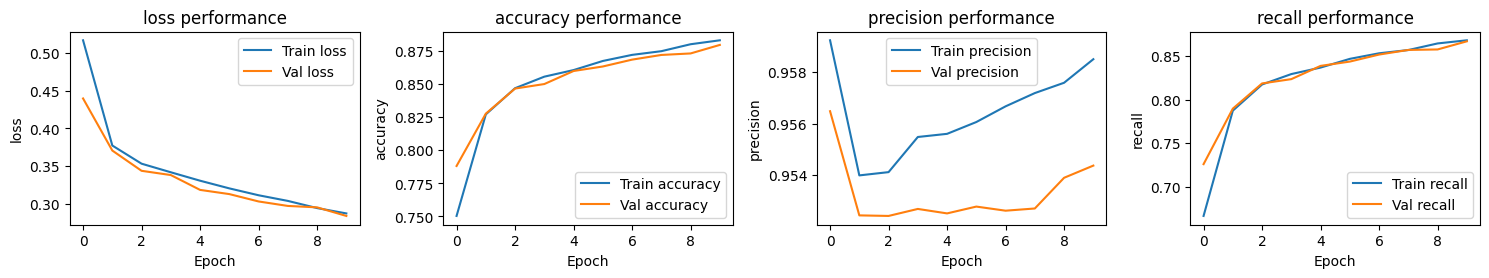

In [ ]:
import matplotlib.pyplot as plt

def plot_performance_metrics(history):
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    plt.figure(figsize=(15, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(4, 4, i+1)
        plt.plot(history.history[metric], label='Train ' + metric)
        plt.plot(history.history['val_' + metric], label='Val ' + metric)
        plt.title(f'{metric} performance')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_performance_metrics(history)

Export for later use

In [ ]:
import tensorflow as tf

# Export
model.save('neural_network_classifier.keras')

# Import
loaded_model = tf.keras.models.load_model(
    "neural_network_classifier.keras"
)

# Inference
example = "I am feeling great"
preds = loaded_model.predict(tf.constant([[example]], dtype=tf.string))
print(preds) # closer to 1 should indicate abnormal

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
[[0.12322558]]


# Ariel (Multiclass LSTM)

In [65]:
test = "/content/drive/Shareddrives/171Project/dataset/features_test.csv"
train = "/content/drive/Shareddrives/171Project/dataset/features_train.csv"
val = "/content/drive/Shareddrives/171Project/dataset/features_val.csv"

In [66]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import KFold
import re

In [67]:
from collections import Counter
train_df=pd.read_csv(train)
val_df=pd.read_csv(val)
test_df=pd.read_csv(test)
all_data = pd.concat([train_df, val_df, test_df])
all_data.head()

,statement,status,tfidf_vec,count_vec,bert_features,first_person_ratio,negatives_ratio,suicide_ratio,reps_ratio,character_count,word_count,avg_word_length,avg_sentence_length_in_words,avg_sentence_length_in_characters,sia_sentiment
0,to put some context i have been though some th...,suicidal,[0.04838083 0. 0. 0.02265681 0...,[ 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 ...,"tensor([ 1.1332e-01, -3.2757e-02, 9.6535e-02,...",0.154242,0.007712,0.017995,0.562982,1871,389,3.812339,389.0,1871.0,-0.9686
1,michaelgrainger scyranth gigglessssssss yall a...,normal,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-2.6322e-01, 3.6765e-02, -1.6883e-02,...",0.000000,0.000000,0.000000,0.000000,61,6,9.333333,6.0,61.0,0.0000
2,so right now they are planning to meet at the ...,suicidal,[0. 0. 0. 0. 0...,[ 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"tensor([ 1.1049e-01, 7.6769e-02, 1.9305e-01,...",0.120690,0.043103,0.017241,0.431034,517,116,3.465517,116.0,517.0,-0.9249
3,being broke is no fun,normal,[0. 0. 0. 0. 0...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-1.9146e-02, -3.7258e-02, -4.3136e-03,...",0.000000,0.200000,0.000000,0.000000,21,5,3.400000,5.0,21.0,-0.1779
4,you dont need to worry about that,normal,[0. 0. 0. 0.26469062 0...,[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-6.5769e-02, 4.1372e-02, -1.1422e-01,...",0.000000,0.000000,0.000000,0.000000,33,7,3.857143,7.0,33.0,0.3412


In [68]:
def tokenize(text):
    return re.findall(r'\w+', text.lower())

In [69]:
all_words = []
for entry in all_data['statement']:
  for word in tokenize(entry):
    all_words.append(word)

word_int_mapping = {"<PAD>": 0, "<UNK>": 1}
word_counts = Counter(all_words)
for word, count in word_counts.items():
  if count > 1:
    word_int_mapping[word] = len(word_int_mapping)

status_int_mapping = {}
for i,status in enumerate(all_data['status'].unique()):
  status_int_mapping[status] = i

In [70]:
all_data["statement"].apply(lambda x: len(tokenize(x))).describe() #to pick max length

,statement
count,52681.000000
mean,112.912644
std,163.515119
min,0.000000
25%,15.000000
50%,62.000000
75%,148.000000
max,6300.000000


In [71]:
num_statuses = len(status_int_mapping)
pad_to = 150

class TextDataset(Dataset):
  def __init__(self, df):
      self.statement = df["statement"].tolist()
      self.status = df["status"].tolist()

  def encode(self, statement):
      tokens = tokenize(statement)[:pad_to]
      ids = []
      for tok in tokens:
        ids.append(word_int_mapping.get(tok, word_int_mapping["<UNK>"]))
      ids += [word_int_mapping["<PAD>"]] * (pad_to - len(ids))
      return torch.tensor(ids)

  def __len__(self):
      return len(self.statement)

  def __getitem__(self, idx):
      x = self.encode(self.statement[idx])
      y = torch.tensor(status_int_mapping[self.status[idx]], dtype=torch.long)
      return x, y

In [ ]:
class LSTMClassifier(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_dim, num_statuses):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
    self.fc = nn.Linear(hidden_dim * 2, num_statuses)
    self.dropout = nn.Dropout(0.3)

  def forward(self, x):
    embeds = self.embedding(x)
    embeds = self.dropout(embeds)
    _, (hidden, _) = self.lstm(embeds)
    hidden = torch.cat((hidden[0], hidden[1]), dim=1)
    out  = self.fc(self.dropout(hidden))
    return out

In [ ]:
embed_dim  = 64
hidden_dim = 128
lr = 1e-3
num_epochs = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data)):
  print(f"Fold {fold+1}/5")

  train_ds     = TextDataset(all_data.iloc[train_idx].reset_index(drop=True))
  val_ds       = TextDataset(all_data.iloc[val_idx].reset_index(drop=True))

  train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
  val_loader   = DataLoader(val_ds, batch_size=64)

  model     = LSTMClassifier(len(word_int_mapping), embed_dim, hidden_dim, num_statuses).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
      x = x.to(device)
      y = y.to(device)
      optimizer.zero_grad()
      loss = criterion(model(x), y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"  Epoch {epoch+1}/{num_epochs} | loss: {avg_loss:.4f}")

  model.eval()
  correct = 0
  total   = 0
  with torch.no_grad():
    for x, y in val_loader:
      x = x.to(device)
      y = y.to(device)
      scores = model(x)
      _, predicted = torch.max(scores, dim=1)
      for i in range(len(y)):
            total += 1
            if predicted[i] == y[i]:
                correct += 1

  acc = correct / total
  fold_accuracies.append(acc)
  print(f"accuracy: {acc:.3f}")

print(f"\nMean accuracy: {sum(fold_accuracies)/len(fold_accuracies):.3f}")

Fold 1/5
  Epoch 1/30 | loss: 1.1985
  Epoch 2/30 | loss: 0.9197
  Epoch 3/30 | loss: 0.7968
  Epoch 4/30 | loss: 0.7065
  Epoch 5/30 | loss: 0.6418
  Epoch 6/30 | loss: 0.5927
  Epoch 7/30 | loss: 0.5562
  Epoch 8/30 | loss: 0.5292
  Epoch 9/30 | loss: 0.4951
  Epoch 10/30 | loss: 0.4700
  Epoch 11/30 | loss: 0.4469
  Epoch 12/30 | loss: 0.4246
  Epoch 13/30 | loss: 0.4035
  Epoch 14/30 | loss: 0.3873
  Epoch 15/30 | loss: 0.3705
  Epoch 16/30 | loss: 0.3500
  Epoch 17/30 | loss: 0.3373
  Epoch 18/30 | loss: 0.3201
  Epoch 19/30 | loss: 0.3058
  Epoch 20/30 | loss: 0.2972
  Epoch 21/30 | loss: 0.2823
  Epoch 22/30 | loss: 0.2720
  Epoch 23/30 | loss: 0.2620
  Epoch 24/30 | loss: 0.2503
  Epoch 25/30 | loss: 0.2453
  Epoch 26/30 | loss: 0.2322
  Epoch 27/30 | loss: 0.2239
  Epoch 28/30 | loss: 0.2196
  Epoch 29/30 | loss: 0.2095
  Epoch 30/30 | loss: 0.2040
accuracy: 0.790
Fold 2/5
  Epoch 1/30 | loss: 1.1572
  Epoch 2/30 | loss: 0.9214
  Epoch 3/30 | loss: 0.7879
  Epoch 4/30 | loss: 

Exporting for later usage

In [73]:
import json
with open("word2int_mapping.json", "w") as f:
  json.dump(word_int_mapping, f)

In [ ]:

# Export
torch.save(model.state_dict(), "lstm_classifier.pt")
with open("word2int_mapping.json", "w") as f:
  json.dump(word_int_mapping, f)
with open("status2int_mapping.json", "w") as f:
  json.dump(status_int_mapping, f)


In [ ]:
import json
import torch
import re

# Import
with open("word2int_mapping.json", "r") as f:
  loaded_word2int_mapping = json.load(f)
with open("status2int_mapping.json", "r") as f:
  loaded_status2int_mapping = json.load(f)
loaded_int2status_mapping = {value: key for key, value in loaded_status2int_mapping.items()}
vocab_size = len(loaded_word2int_mapping)
embed_dim = 64
hidden_dim = 128
num_statuses = len(loaded_status2int_mapping)
model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_statuses)
model.load_state_dict(torch.load("lstm_classifier.pt", map_location="cuda"))
model.eval()
pad_to = 150
def tokenize(text):
  return re.findall(r'\w+', text.lower())
def encode(statement):
  tokens = tokenize(statement)[:pad_to]
  ids = [loaded_word2int_mapping.get(token, loaded_word2int_mapping["<UNK>"]) for token in tokens]
  ids += [word_int_mapping["<PAD>"]] * (pad_to - len(ids))
  return torch.tensor(ids).unsqueeze(0)

# Inference
text = "I'm busy right now and I feel like I don't have any time"
x = encode(text)
with torch.no_grad():
  logits = model(x)
  pred = torch.argmax(logits, dim=1).item()
print(loaded_int2status_mapping[pred])


normal


# Chengyi (Multiclass BERT)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from transformers import DistilBertTokenizer, DistilBertModel
import torch

# Hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
DROPOUT = 0.3
NUM_EPOCHS = 20
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.1

# 1) Grab the dataset & preprocess the data
print("Loading data...")
train_df = pd.read_csv('/content/drive/Shareddrives/171Project/dataset/features_train.csv')
val_df = pd.read_csv('/content/drive/Shareddrives/171Project/dataset/features_val.csv')
test_df = pd.read_csv('/content/drive/Shareddrives/171Project/dataset/features_test.csv')
train_df = train_df[train_df['status'] != 'normal']
val_df = val_df[val_df['status'] != 'normal']
test_df = test_df[test_df['status'] != 'normal']
text_column = 'statement'
label_column = 'status'
label_encoder = LabelEncoder()
train_df[label_column] = label_encoder.fit_transform(train_df[label_column])
val_df[label_column] = label_encoder.transform(val_df[label_column])
test_df[label_column] = label_encoder.transform(test_df[label_column])
train_df[label_column] = [torch.tensor(label, dtype=torch.long) for label in train_df[label_column]]
val_df[label_column] = [torch.tensor(label, dtype=torch.long) for label in val_df[label_column]]
test_df[label_column] = [torch.tensor(label, dtype=torch.long) for label in test_df[label_column]]

# 2) Format data into dataloaders
print("Formatting data...")
class CustomDataset(Dataset):
    def __init__(self, df, text_column, label_column):
        self.df = df
        self.text_column = text_column
        self.label_column = label_column
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        return {
            'text': self.df.iloc[idx][self.text_column],
            'label': self.df.iloc[idx][self.label_column],
        }
train_data = CustomDataset(train_df, text_column, label_column)
val_data = CustomDataset(val_df, text_column, label_column)
test_data = CustomDataset(test_df, text_column, label_column)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_df, batch_size=BATCH_SIZE)

# 3) Set up the pretrained model + fully connected model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TOKENIZER = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
MODEL = DistilBertModel.from_pretrained('distilbert-base-uncased')
print("Using:", DEVICE)
MODEL = MODEL.to(DEVICE)
for param in MODEL.parameters():
    param.requires_grad = False
hidden_size = 768
numerical_size = len(['first_person', 'negatives', 'suicide', 'reps'])
concatenated_size = hidden_size + numerical_size
num_classes = int(train_df[label_column].max()) + 1
CLASSIFIER = nn.Sequential(
    nn.Linear(concatenated_size, hidden_size),
    nn.Dropout(DROPOUT),
    nn.ReLU(),
    nn.Linear(hidden_size, num_classes),
)
CLASSIFIER = CLASSIFIER.to(DEVICE)
def word_ratio(text: str, provided_words):
  words = text.split()
  count = 0
  for word in words:
    if word in provided_words:
      count += 1
  return count/max(len(words), 1)
def reps_ratio(text: str):
  words = text.split()
  unique_words = set()
  for word in words:
    unique_words.add(word)
  return 1 - len(unique_words) / max(len(words), 1)
FIRST_PERSON = ['i', 'me', 'my', 'mine', 'myself']
NEGATIVES = ['no', 'not', 'never', 'nothing', 'wrong', 'nope']
SUICIDE_WORDS = ['die', 'end', 'forever', 'leave', 'gone', 'suicide', 'kill']
def forward(texts):
    encoding = TOKENIZER(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
    outputs = MODEL(**encoding)
    embeddings = outputs.last_hidden_state[:, 0, :]
    embeddings = embeddings.to(DEVICE)
    numerical_features = []
    for text in texts:
        first_person_ratio = word_ratio(text, FIRST_PERSON)
        negatives_ratio = word_ratio(text, NEGATIVES)
        suicide_ratio = word_ratio(text, SUICIDE_WORDS)
        repeat_ratio = reps_ratio(text)
        numerical_features.append([first_person_ratio, negatives_ratio, suicide_ratio, repeat_ratio])
    numerical_features = torch.tensor(numerical_features, dtype=torch.float32)
    numerical_features = numerical_features.to(DEVICE)
    combined_features = torch.cat([embeddings, numerical_features], dim=1)
    combined_features = combined_features.to(DEVICE)
    logits = CLASSIFIER(combined_features)
    del embeddings
    del outputs
    del numerical_features
    del combined_features
    torch.cuda.empty_cache()
    return logits

# 4) Set up training for these models
optimizer = torch.optim.AdamW([{'params': MODEL.parameters(), 'lr': 2e-5}, {'params': CLASSIFIER.parameters(), 'lr': 1e-4}], weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
print("Training...")
print()
for epoch in range(NUM_EPOCHS):
    CLASSIFIER.train()
    if epoch == (NUM_EPOCHS // 2):
        for param in MODEL.parameters():
            param.requires_grad = True
            MODEL.train()
    train_loss = 0
    for batch in train_loader:
        texts = batch['text']
        labels = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        logits = forward(texts)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        del labels
        torch.cuda.empty_cache()
        train_loss += loss.item()
    CLASSIFIER.eval()
    MODEL.eval()
    val_loss = 0
    correct_preds = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            texts = batch['text']
            labels = batch['label'].to(DEVICE)
            logits = forward(texts)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            y_pred = torch.argmax(logits, dim=1)
            correct_preds += (y_pred == labels).sum().item()
            total += labels.size()[0]
            del labels
            torch.cuda.empty_cache()
    print(f"Epoch {epoch+1} done")
    print(f" Train loss: {train_loss/len(train_loader)}")
    print(f" Val loss: {val_loss/len(val_loader)}")
    print(f" Val accuracy: {100*correct_preds/total}%")
    print()
    if (epoch+1 == 12): # Empirically chosen best model
      torch.save({
          'bert_state_dict': MODEL.state_dict(),
          'classifier_state_dict': CLASSIFIER.state_dict(),
      }, f"bert_classifier.pt")
    else:
      torch.save({
          'bert_state_dict': MODEL.state_dict(),
          'classifier_state_dict': CLASSIFIER.state_dict(),
      }, f"model_epoch{epoch+1}.pt")
print("Done")


Loading data...
Formatting data...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using: cuda
Training...

Epoch 1 done
 Train loss: 1.212030191354032
 Val loss: 1.1156929584542328
 Val accuracy: 62.22711429095579%

Epoch 2 done
 Train loss: 1.0904344859363149
 Val loss: 1.0634840901646097
 Val accuracy: 65.21739130434783%

Epoch 3 done
 Train loss: 1.0502968887113175
 Val loss: 1.0400348289970778
 Val accuracy: 66.75839295542103%

Epoch 4 done
 Train loss: 1.025077302163502
 Val loss: 1.0202351502659035
 Val accuracy: 67.43716749220327%

Epoch 5 done
 Train loss: 1.0108747939268747
 Val loss: 1.011905565289808
 Val accuracy: 67.1619886259402%

Epoch 6 done
 Train loss: 0.9967563459708256
 Val loss: 1.005659796800082
 Val accuracy: 68.02421574023116%

Epoch 7 done
 Train loss: 0.9886529761665273
 Val loss: 0.9915781923053552
 Val accuracy: 68.94147862777471%

Epoch 8 done
 Train loss: 0.9795418833786587
 Val loss: 0.9871310441375128
 Val accuracy: 68.97816914327646%

Epoch 9 done
 Train loss: 0.97277385453758
 Val loss: 0.9821900590773551
 Val accuracy: 69.491836360

Exporting for later use

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel
import torch.nn as nn
import re
import joblib

# Imports
bert_path = "bert_classifier.pt"
encoder_path = "label_encoder.joblib"
ENCODER = joblib.load(encoder_path)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(bert_path, map_location=DEVICE)
TOKENIZER = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
MODEL = DistilBertModel.from_pretrained(pretrained_model_name_or_path="distilbert-base-uncased")
MODEL.load_state_dict(checkpoint["bert_state_dict"])
numerical_size = 4
hidden_size = 768
num_classes = checkpoint['classifier_state_dict']['3.weight'].shape[0]
CLASSIFIER = nn.Sequential(
    nn.Linear(hidden_size + numerical_size, hidden_size),
    nn.Dropout(0.3),
    nn.ReLU(),
    nn.Linear(hidden_size, num_classes),
)
CLASSIFIER.load_state_dict(checkpoint['classifier_state_dict'])
MODEL = MODEL.to(DEVICE)
CLASSIFIER = CLASSIFIER.to(DEVICE)
MODEL.eval()
CLASSIFIER.eval()

# Definitions
def word_ratio(text: str, provided_words):
  words = text.split()
  count = 0
  for word in words:
    if word in provided_words:
      count += 1
  return count/max(len(words), 1)

def reps_ratio(text: str):
  words = text.split()
  unique_words = set()
  for word in words:
    unique_words.add(word)
  return 1 - len(unique_words) / max(len(words), 1)

FIRST_PERSON = ['i', 'me', 'my', 'mine', 'myself']
NEGATIVES = ['no', 'not', 'never', 'nothing', 'wrong', 'nope']
SUICIDE_WORDS = ['die', 'end', 'forever', 'leave', 'gone', 'suicide', 'kill']

def forward(texts):
    encoding = TOKENIZER(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
    outputs = MODEL(**encoding)
    embeddings = outputs.last_hidden_state[:, 0, :]
    embeddings = embeddings.to(DEVICE)
    numerical_features = []
    for text in texts:
        first_person_ratio = word_ratio(text, FIRST_PERSON)
        negatives_ratio = word_ratio(text, NEGATIVES)
        suicide_ratio = word_ratio(text, SUICIDE_WORDS)
        repeat_ratio = reps_ratio(text)
        numerical_features.append([first_person_ratio, negatives_ratio, suicide_ratio, repeat_ratio])
    numerical_features = torch.tensor(numerical_features, dtype=torch.float32)
    numerical_features = numerical_features.to(DEVICE)
    combined_features = torch.cat([embeddings, numerical_features], dim=1)
    combined_features = combined_features.to(DEVICE)
    logits = CLASSIFIER(combined_features)
    del embeddings
    del outputs
    del numerical_features
    del combined_features
    torch.cuda.empty_cache()
    return logits

# Inference
text = ["I'm too busy right now. There's too many things going on."]
with torch.no_grad():
  logits = forward(text)
  pred = torch.argmax(logits, dim=1).item()
  print(pred)
print(ENCODER.inverse_transform([pred])[0])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2
depression
